# Assignment 3: Predicting Future Outcomes

## Import necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.stats.api as sms
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import imblearn
import nltk
import re

# Data preprocessing and transformation
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE

# Regression and classification
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn import linear_model, metrics, tree
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

# Model evaluation
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score,
    confusion_matrix, classification_report, silhouette_score
)

# Statsmodels
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

# NLP and visualisation
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import warnings  
warnings.filterwarnings('ignore')  

## Set Chart Style and Formats

In [2]:
# chart_style.py
import matplotlib.pyplot as plt
import seaborn as sns

# Define colour palette
hex_colours = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    ]

# Line styles
line_styles = ['-']

# Seaborn theme
sns.set_theme(style='white')
sns.color_palette(hex_colours)

# Format charts
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'figure.facecolor': 'white',

    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'arial',

    'axes.edgecolor': 'grey',
    'axes.linewidth': 1,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.grid': False,

    'legend.loc': 'best',
    'legend.frameon': True,

    'lines.linewidth': 2,
    'lines.markersize': 6,
})


# Exploratory Data Analysis

1. Import Data
2. Remove unnecessary columns and configure data types
4. View shape of data
5. Visualise distribution of variables

Remove redundant columns and assess data

In [3]:
# Load the data set
tg = pd.read_csv('turtle_reviews.csv')

# View the DataFrame
tg_df = pd.DataFrame(tg)

# Change names of columns
tg_df = tg_df.rename(columns={
    'remuneration (k£)': 'income',
    'spending_score (1-100)' : 'spend_score'
})

# Remove redundant columns and change product to object
tg_df = tg_df.drop(['language','platform'], axis = 1)
tg_df['product'] = tg_df['product'].astype('object')
tg_df

,gender,age,income,spend_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,1031,fun game!,Four Stars


In [4]:
# Save cleaned data
tg_df.to_csv('turtle_clean2.csv', index = False)


Distribution of 'gender':
gender
Female    1120
Male       880
Name: count, dtype: int64

Distribution of 'education':
education
graduate        900
PhD             460
postgraduate    400
diploma         190
Basic            50
Name: count, dtype: int64


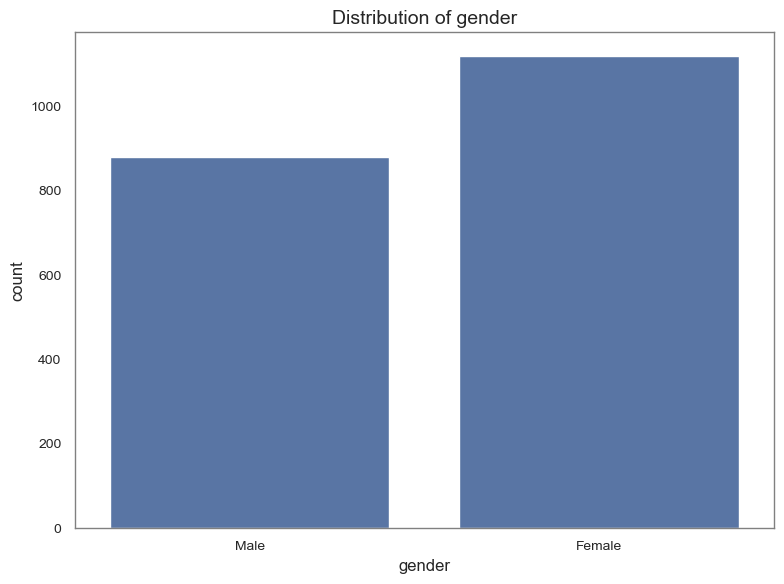

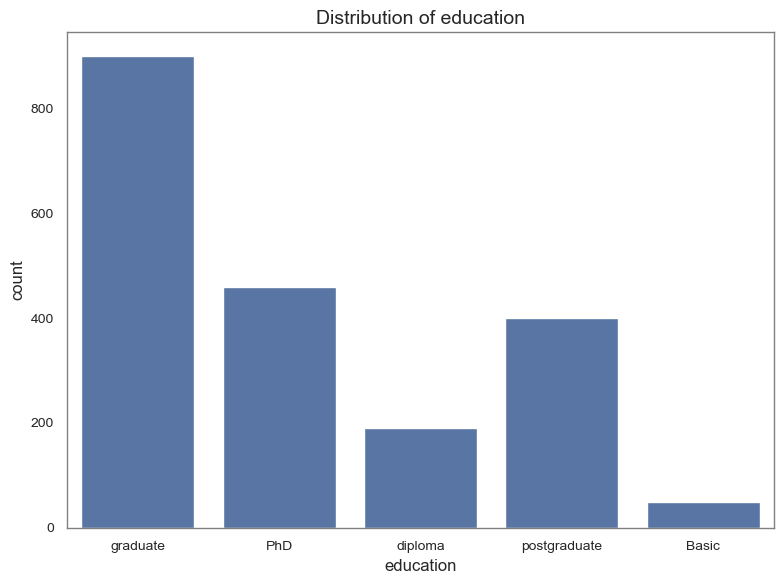

In [5]:
# Plot distributions of categorical data
categorical_cols = ['gender', 'education']

for col in categorical_cols:
    print(f"\nDistribution of '{col}':")
    print(tg_df[col].value_counts())

for col in categorical_cols:
    plt.figure()
    sns.countplot(x=col, data=tg_df)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.savefig(f'Distribution of {col}.png',dpi=300)
    plt.show()

               age       income  spend_score  loyalty_points
count  2000.000000  2000.000000  2000.000000     2000.000000
mean     39.495000    48.079060    50.000000     1578.032000
std      13.573212    23.123984    26.094702     1283.239705
min      17.000000    12.300000     1.000000       25.000000
25%      29.000000    30.340000    32.000000      772.000000
50%      38.000000    47.150000    50.000000     1276.000000
75%      49.000000    63.960000    73.000000     1751.250000
max      72.000000   112.340000    99.000000     6847.000000


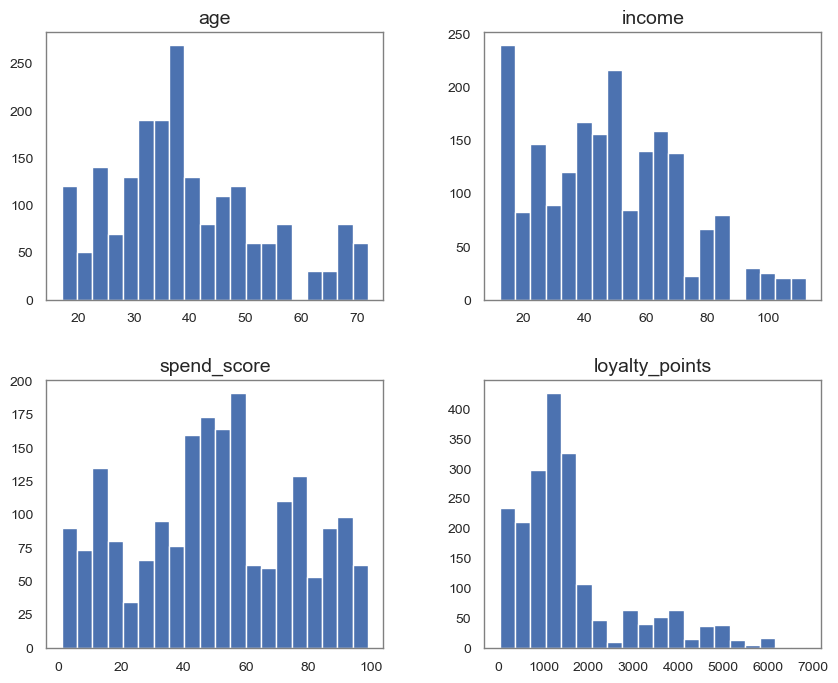

In [6]:
# Plot distribution of numerical data
numeric_cols = ['age', 'income', 'spend_score', 'loyalty_points']

# Describe
print(tg_df[numeric_cols].describe())

tg_df[numeric_cols].hist(bins=20, figsize=(10,8), layout=(2, 2), grid=False)
plt.savefig(f'Distribution of {numeric_cols}.png',dpi=300)
plt.show()

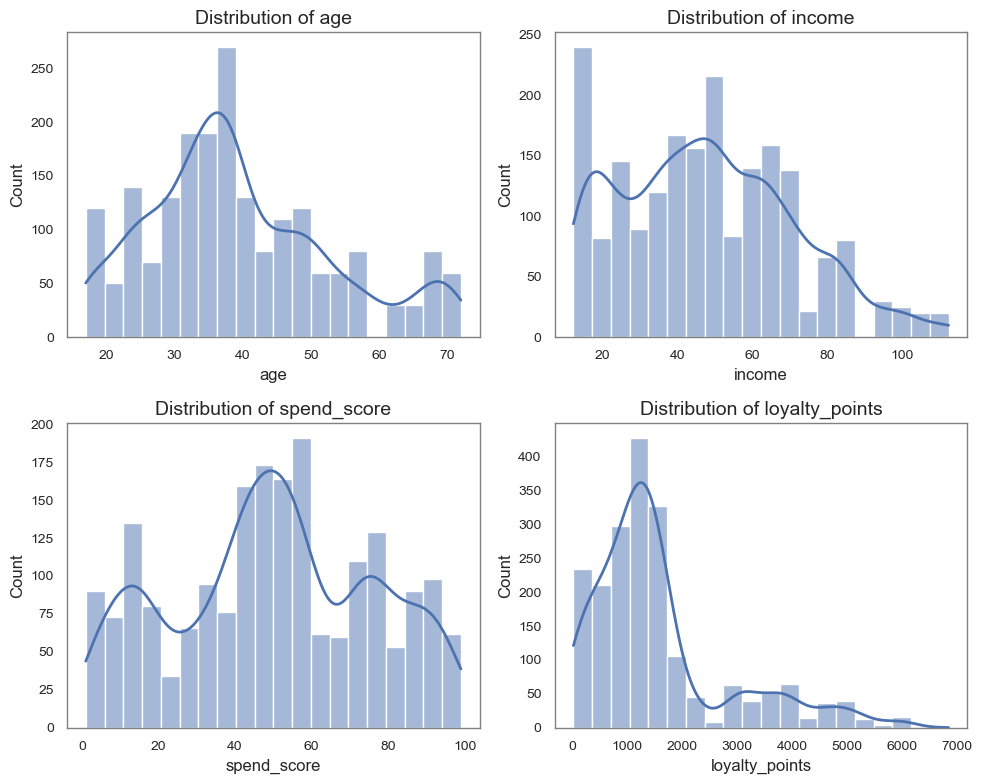

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=tg_df, x=col, kde=True, ax=axes[i], bins=20)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].grid(False)

plt.tight_layout()
plt.savefig(f'Distribution of {numeric_cols} with KDE.png', dpi=300)
plt.show()

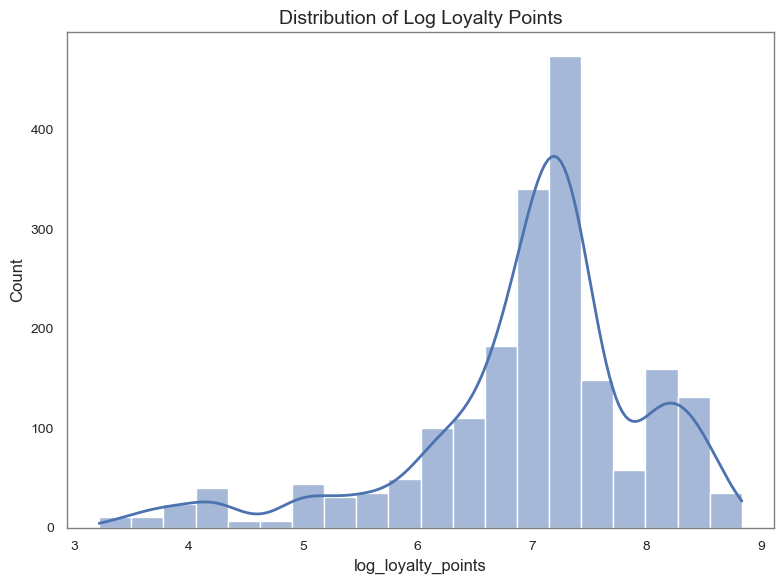

In [8]:
# Natural log of loyalty points
tg_df['log_loyalty_points'] = np.log(tg_df['loyalty_points'])

# Plot log loyalty distribution
sns.histplot(data=tg_df, x='log_loyalty_points', kde=True, bins=20)
plt.title(f'Distribution of Log Loyalty Points')
plt.grid(False)
plt.tight_layout()
plt.savefig(f'Distribution of Log Loyalty Points.png', dpi=300)
plt.show()

## Linear Regression Analysis


==== Linear Regression: income vs Loyalty Points ====



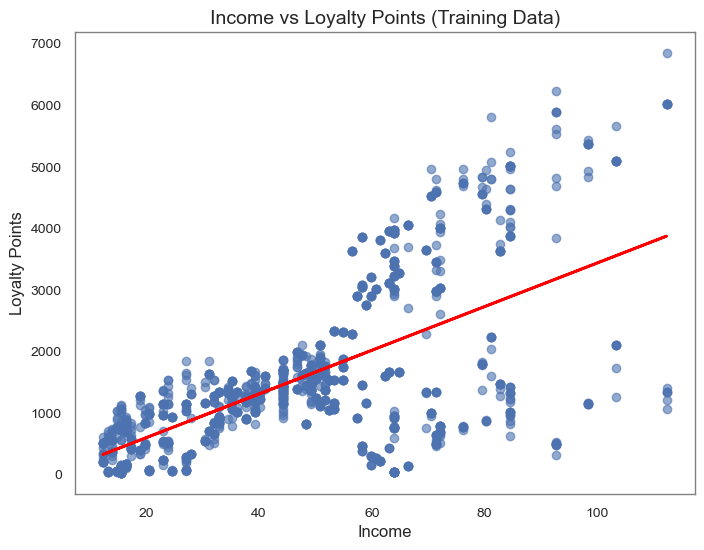

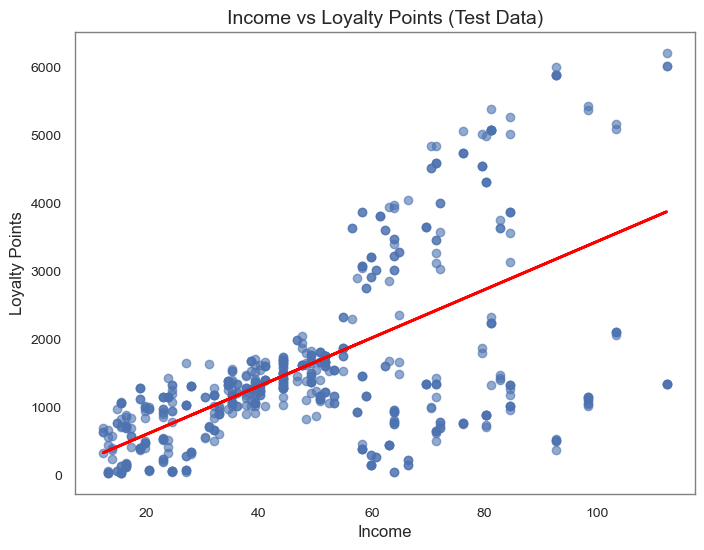

R-squared value: 0.3217
Intercept value: -105.23352858894032
Coefficient value: 35.45189173418371

==== Linear Regression: spend_score vs Loyalty Points ====



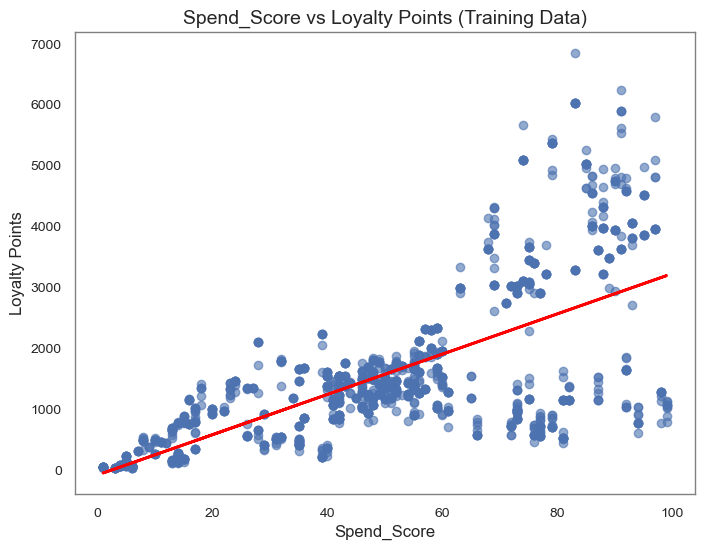

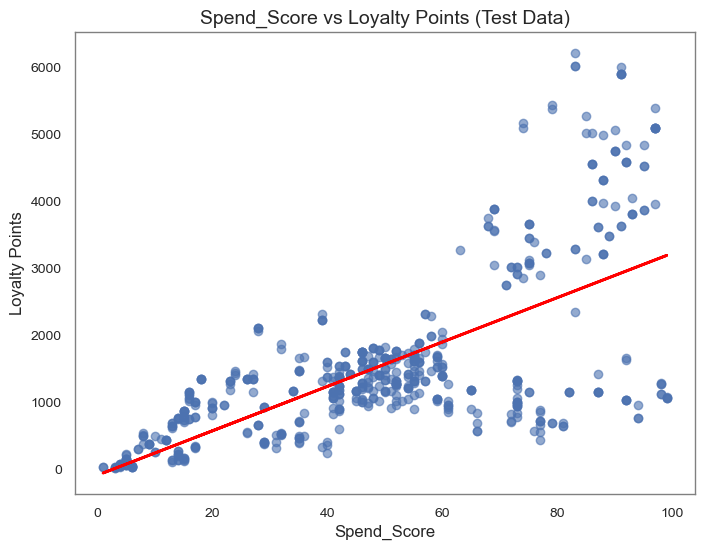

R-squared value: 0.4608
Intercept value: -84.00222800235792
Coefficient value: 33.093717608782434

==== Linear Regression: age vs Loyalty Points ====



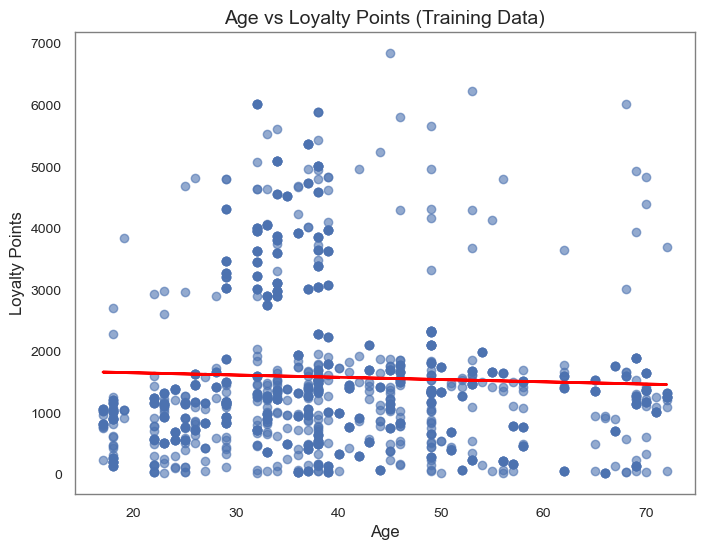

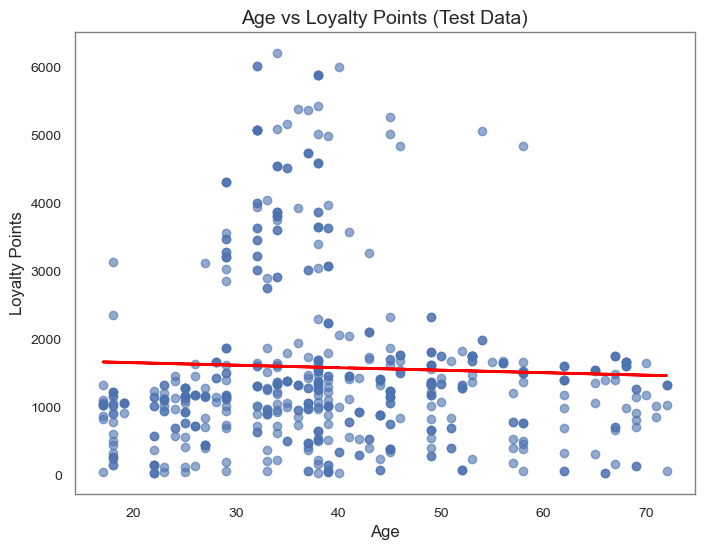

R-squared value: 0.0021
Intercept value: 1730.4451807020332
Coefficient value: -3.675162077931267


In [9]:
# List of independent variables
independent_vars = ['income', 'spend_score', 'age']

# Loop through independent variables to perform linear regression and plot model
for var in independent_vars:
    print(f"\n==== Linear Regression: {var} vs Loyalty Points ====\n")

    # Define independent and dependent variables
    X = tg_df[[var]].values
    y = tg_df[['loyalty_points']].values

    # Split data
    x_train, x_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=0.3,
                                                        random_state=42)

    # Run linear regression model
    lr = LinearRegression()
    lr.fit(x_train, y_train)
    y_pred = lr.predict(x_test)

    # Plot training data
    plt.scatter(x_train, y_train, alpha = 0.6)
    plt.plot(x_train, lr.predict(x_train), color='red',  label='Regression Line')
    plt.title(f"{var.title()} vs Loyalty Points (Training Data)")
    plt.xlabel(var.title())
    plt.ylabel("Loyalty Points")
    plt.savefig(f'{var} vs Loyalty Points (Training Data).png',dpi=300)
    plt.show()

    # Plot test data
    plt.scatter(x_test, y_test, alpha = 0.6 )
    plt.plot(x_train, lr.predict(x_train), color='red',  label='Regression Line')
    plt.title(f"{var.title()} vs Loyalty Points (Test Data)")
    plt.xlabel(var.title())
    plt.ylabel("Loyalty Points")
    plt.savefig(f'{var} vs Loyalty Points (Test Data).png',dpi=300)
    plt.show()

    # Print regression metrics
    print("R-squared value:", round(lr.score(x_test, y_test), 4))
    print("Intercept value:", lr.intercept_[0])
    print("Coefficient value:", lr.coef_[0][0])


### Linear regression on log of loyalty points


==== Linear Regression: income vs Loyalty Points ====



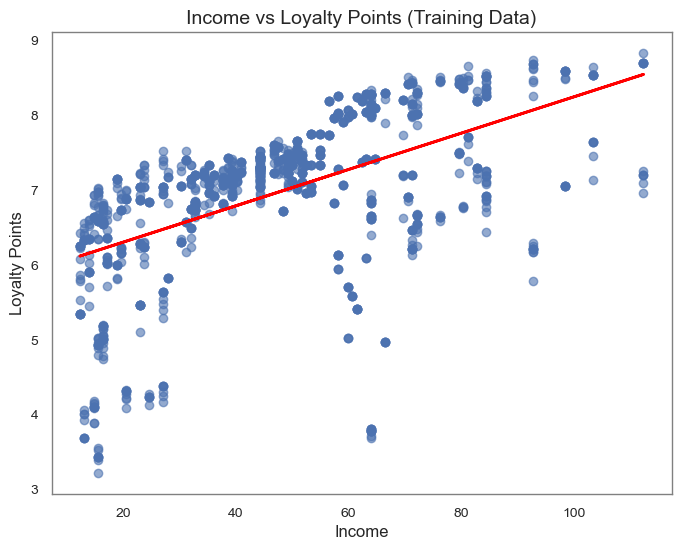

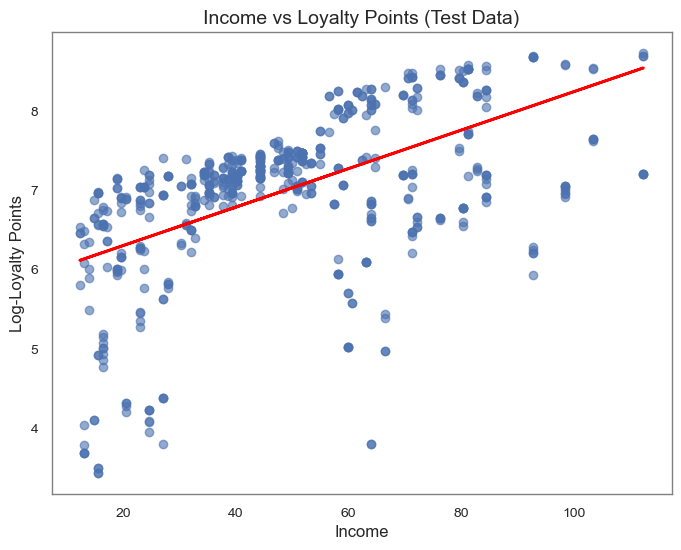

R-squared value: 0.2606
Intercept value: 5.821531471470313
Coefficient value: 0.02427481983219927

==== Linear Regression: spend_score vs Loyalty Points ====



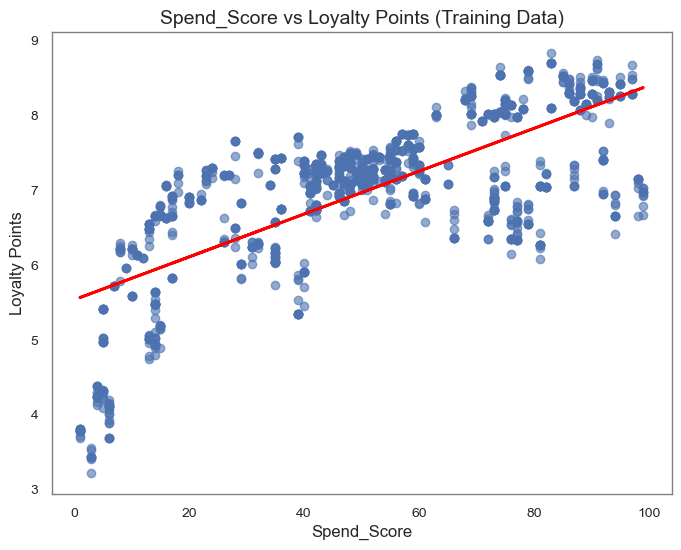

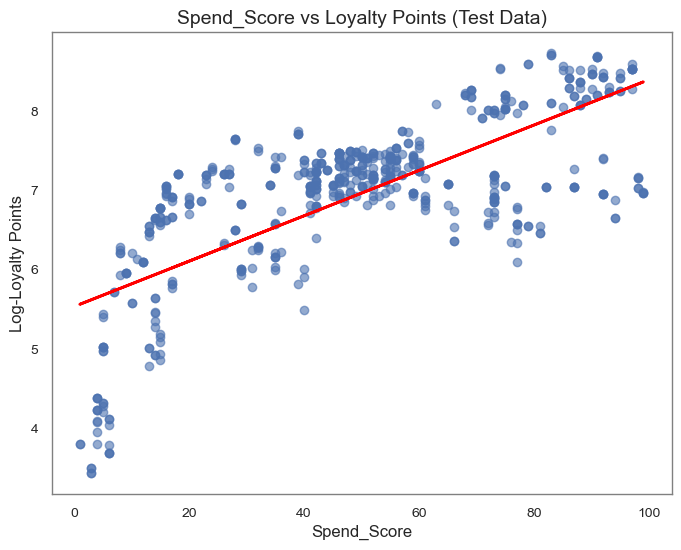

R-squared value: 0.5087
Intercept value: 5.5342471969365326
Coefficient value: 0.028644660782347245

==== Linear Regression: age vs Loyalty Points ====



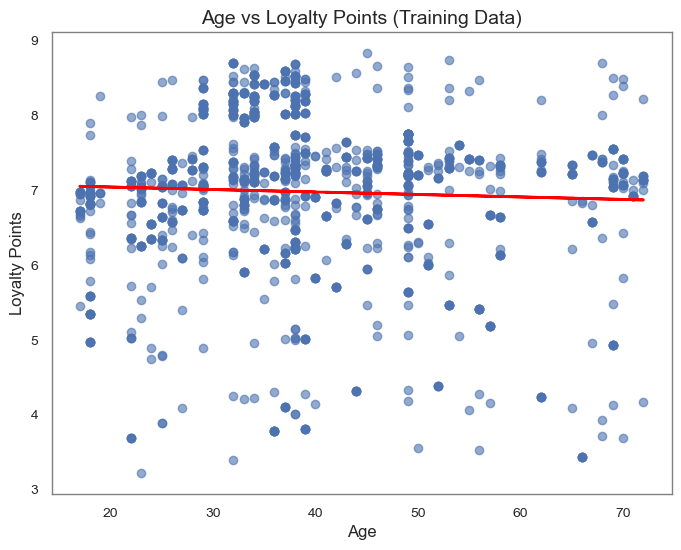

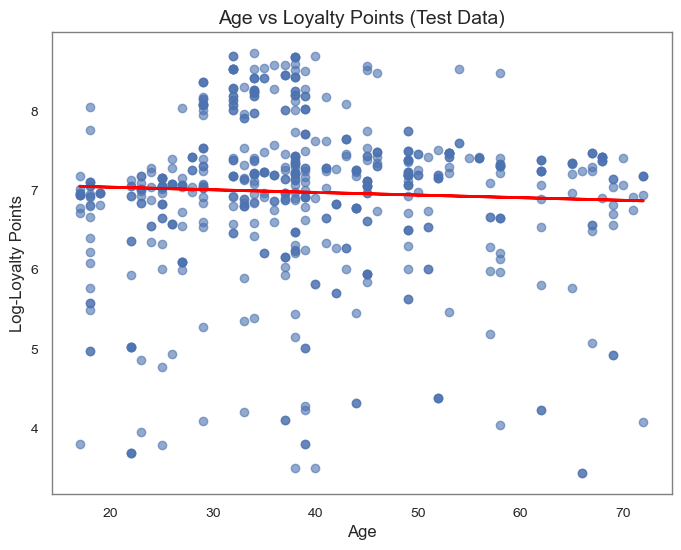

R-squared value: -0.0011
Intercept value: 7.10997571624758
Coefficient value: -0.00331280781283329


In [10]:
# List of independent variables
independent_vars = ['income', 'spend_score', 'age']

for var in independent_vars:
    print(f"\n==== Linear Regression: {var} vs Loyalty Points ====\n")

    # Define independent and dependent variables
    X = tg_df[[var]].values
    y = tg_df[['log_loyalty_points']].values

    # Split data
    x_train, x_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=0.3,
                                                        random_state=42)

    # Run linear regression model
    lr = LinearRegression()
    lr.fit(x_train, y_train)
    y_pred = lr.predict(x_test)

    # Plot training data
    plt.scatter(x_train, y_train, alpha = 0.6)
    plt.plot(x_train, lr.predict(x_train), color='red',  label='Regression Line')
    plt.title(f"{var.title()} vs Loyalty Points (Training Data)")
    plt.xlabel(var.title())
    plt.ylabel("Loyalty Points")
    plt.savefig(f'{var} vs Loyalty Points (Training Data).png',dpi=300)
    plt.show()

    # Plot test data
    plt.scatter(x_test, y_test, alpha = 0.6)
    plt.plot(x_train, lr.predict(x_train), color='red',  label='Regression Line')
    plt.title(f"{var.title()} vs Loyalty Points (Test Data)")
    plt.xlabel(var.title())
    plt.ylabel("Log-Loyalty Points")
    plt.savefig(f'{var} vs Log-Loyalty Points (Test Data).png',dpi=300)
    plt.show()

    # Print regression metrics
    print("R-squared value:", round(lr.score(x_test, y_test), 4))
    print("Intercept value:", lr.intercept_[0])
    print("Coefficient value:", lr.coef_[0][0])

## Multiple Regression

Perform mutliple regression analysis using income and spending score as the independent variables to predict loyalty points

In [11]:
# Define multiple independent variables
X = tg_df[['income', 'spend_score']].values

# Define dependent variable
y = tg_df['loyalty_points'].values

# Split the data
m_X_train, m_X_test, m_y_train, m_y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)
# Add constant
m_Xc_train = sm.add_constant(m_X_train)
m_Xc_test = sm.add_constant(m_X_test)

# Fit the model
multi_model = sm.OLS(m_y_train, m_Xc_train).fit()

# Set the predicted response vector.
Y_pred_m = multi_model.predict(m_Xc_test) 

# Summary of the model.
print_model = multi_model.summary()

# Print the summary.
print(print_model)  

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     3446.
Date:                Mon, 28 Jul 2025   Prob (F-statistic):               0.00
Time:                        12:19:38   Log-Likelihood:                -10764.
No. Observations:                1400   AIC:                         2.153e+04
Df Residuals:                    1397   BIC:                         2.155e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1697.8113     42.064    -40.363      0.0

In [12]:
# MSE
print('Mean Square Error (MLR):', metrics.mean_squared_error(m_y_test, Y_pred_m))  

Mean Square Error (MLR): 299499.00922956306


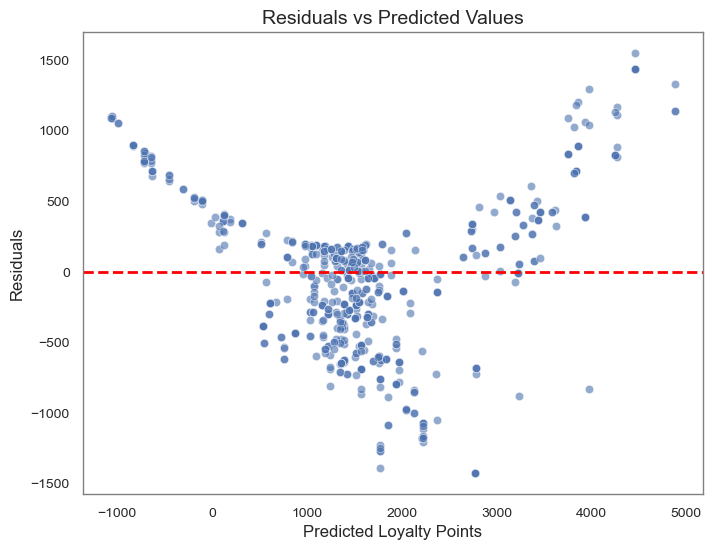

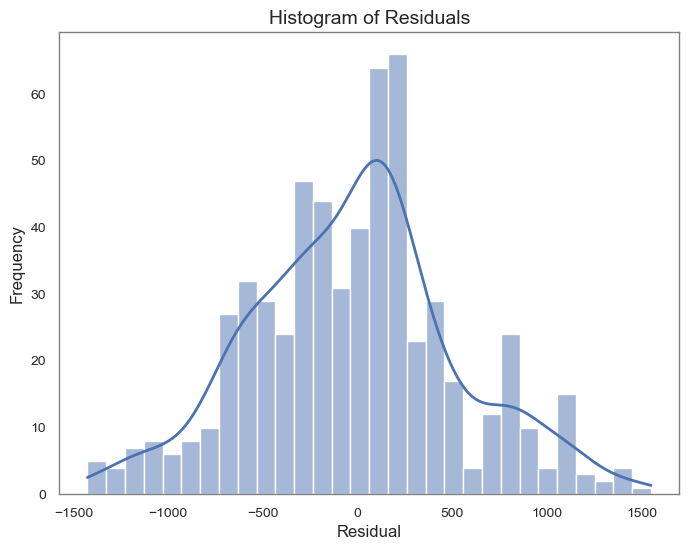

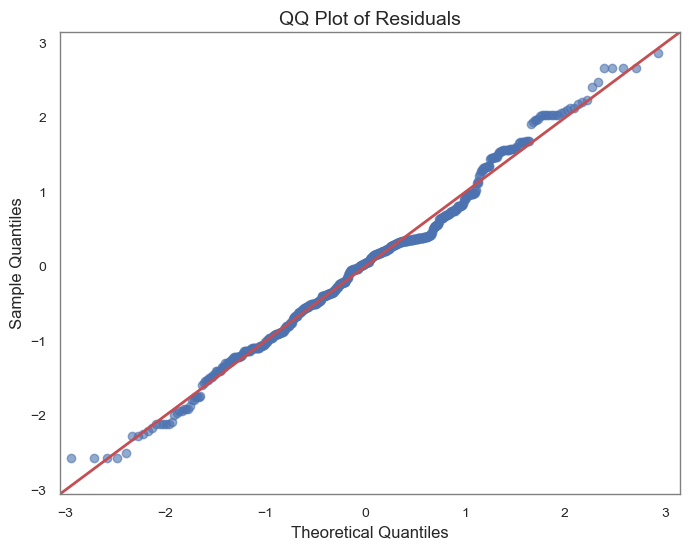

In [13]:
# Calculate residuals
residuals = m_y_test - Y_pred_m

# Residuals vs Predicted Values
plt.figure()
sns.scatterplot(x=Y_pred_m, y=residuals, alpha = 0.6)
plt.axhline(y=0, color='red', linestyle = '--')
plt.xlabel("Predicted Loyalty Points")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.savefig(f'Residuals vs Predicted Values.png',dpi=300)
plt.show()

# Histogram of residuals
plt.figure()
sns.histplot(residuals.flatten(), kde=True, bins=30)
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.savefig(f'Histogram of Residuals.png',dpi=300)
plt.show()

# QQ Plot
import statsmodels.api as sm
sm.qqplot(residuals.flatten(), line='45', alpha=0.6, fit=True)
plt.title("QQ Plot of Residuals")
plt.savefig(f'QQ Plot of Residuals.png',dpi=300)
plt.show()

### Multiple regression on Log of loyalty points

In [14]:
# Define multiple independent variables
X = tg_df[['income', 'spend_score']].values

# Define dependent variable
y = tg_df['log_loyalty_points'].values

# Split the data
m_X_train, m_X_test, m_ly_train, m_ly_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)
# Add constant
m_Xc_train = sm.add_constant(m_X_train)
m_Xc_test = sm.add_constant(m_X_test)

# Fit the model
multi_model = sm.OLS(m_ly_train, m_Xc_train).fit()

# Set the predicted response vector.
lY_pred_m = multi_model.predict(m_Xc_test) 

# Call a summary of the model.
print_model = multi_model.summary()

# Print the summary.
print(print_model)  

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     2755.
Date:                Mon, 28 Jul 2025   Prob (F-statistic):               0.00
Time:                        12:19:40   Log-Likelihood:                -912.39
No. Observations:                1400   AIC:                             1831.
Df Residuals:                    1397   BIC:                             1847.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4366      0.037    120.039      0.0

In [15]:
# MSE
print('Mean Square Error (MLR):', metrics.mean_squared_error(m_ly_test, lY_pred_m))  

Mean Square Error (MLR): 0.19506385106740895


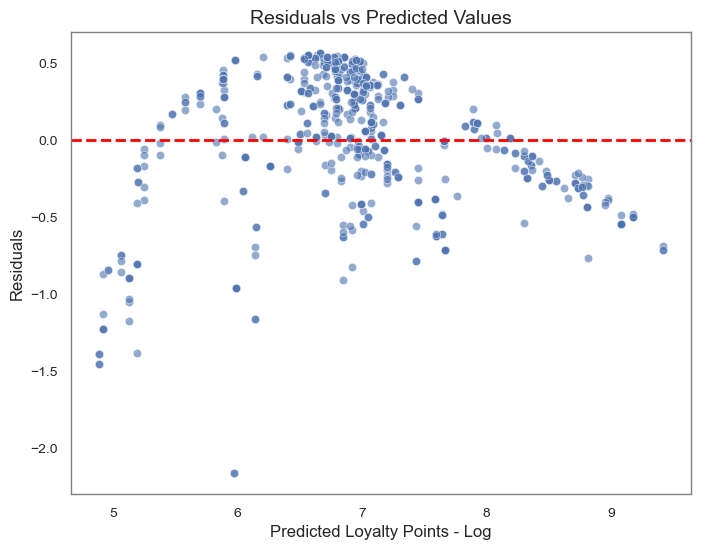

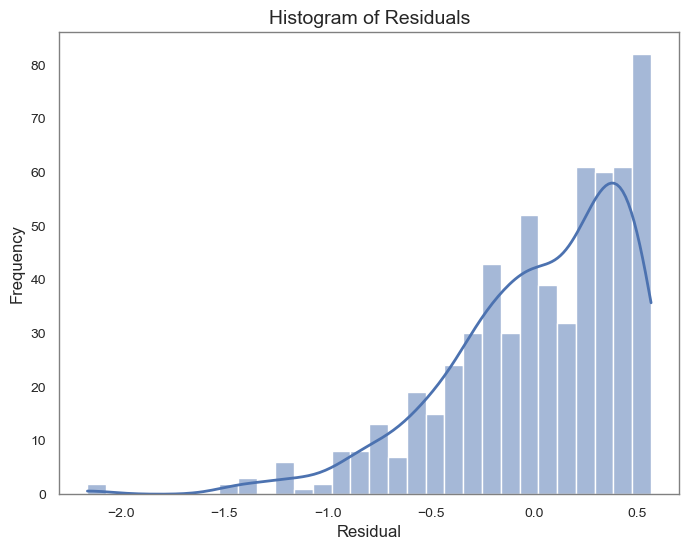

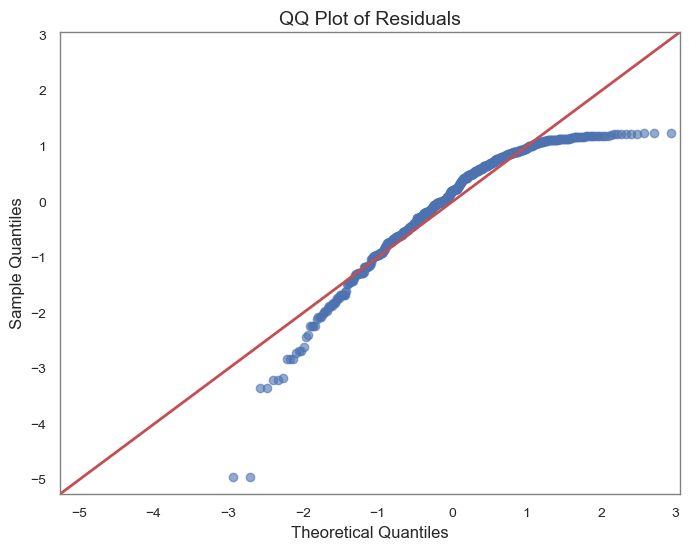

In [16]:
# Residuals
residuals = m_ly_test - lY_pred_m

# Residuals vs Predicted Values
plt.figure()
sns.scatterplot(x=lY_pred_m, y=residuals, alpha = 0.6)
plt.axhline(y=0, color='red', linestyle = '--')
plt.xlabel("Predicted Loyalty Points - Log")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.savefig(f'Residuals vs Predicted Values - logLoyalty.png',dpi=300)
plt.show()

# Histogram of residuals
plt.figure()
sns.histplot(residuals.flatten(), kde=True, bins=30)
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.savefig(f'Histogram of Residuals - logLoyalty.png',dpi=300)
plt.show()

# QQ Plot
import statsmodels.api as sm
sm.qqplot(residuals.flatten(), line='45', alpha=0.6, fit=True)
plt.title("QQ Plot of Residuals")
plt.savefig(f'QQ Plot of Residuals - logLoyalty.png',dpi=300)
plt.show()

## Decision Tree Regression

income & spending score v loyalty point

Mean Squared Error: 101463.45
R² Score: 0.9374


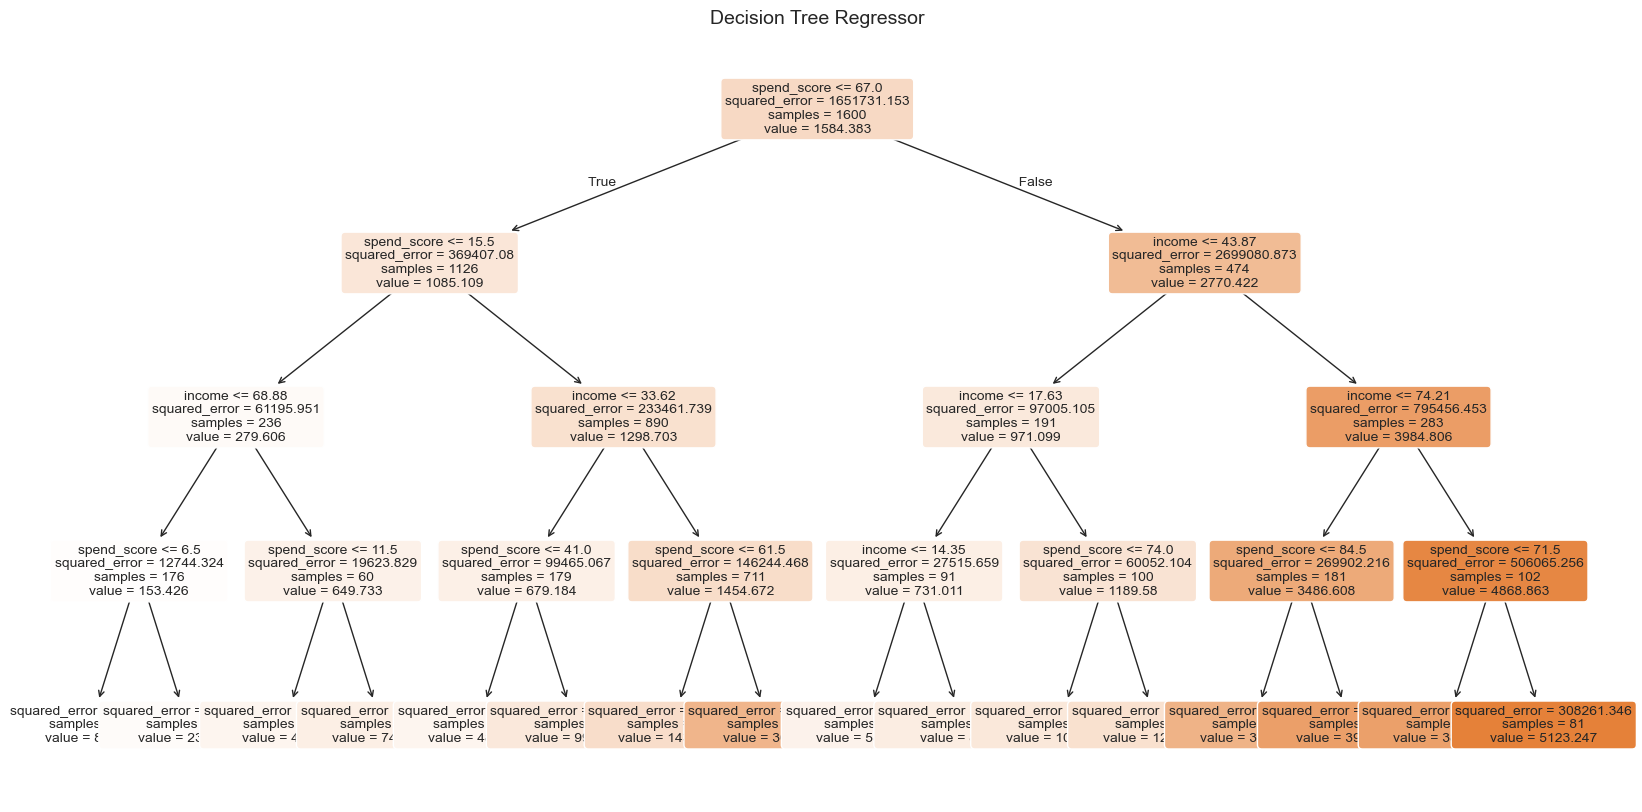

In [17]:
# Define variables
X = tg_df[['income', 'spend_score']]
y = tg_df['loyalty_points']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit the model
tree_model = DecisionTreeRegressor(random_state=42, max_depth=4) 
tree_model.fit(X_train, y_train)

# Predict
y_pred = tree_model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Regressor")
plt.savefig(f'Decision Tree Regressor.png',dpi=300)
plt.show()

### income & spending score vs log of loyalty points

Mean Squared Error: 0.04
R² Score: 0.9612


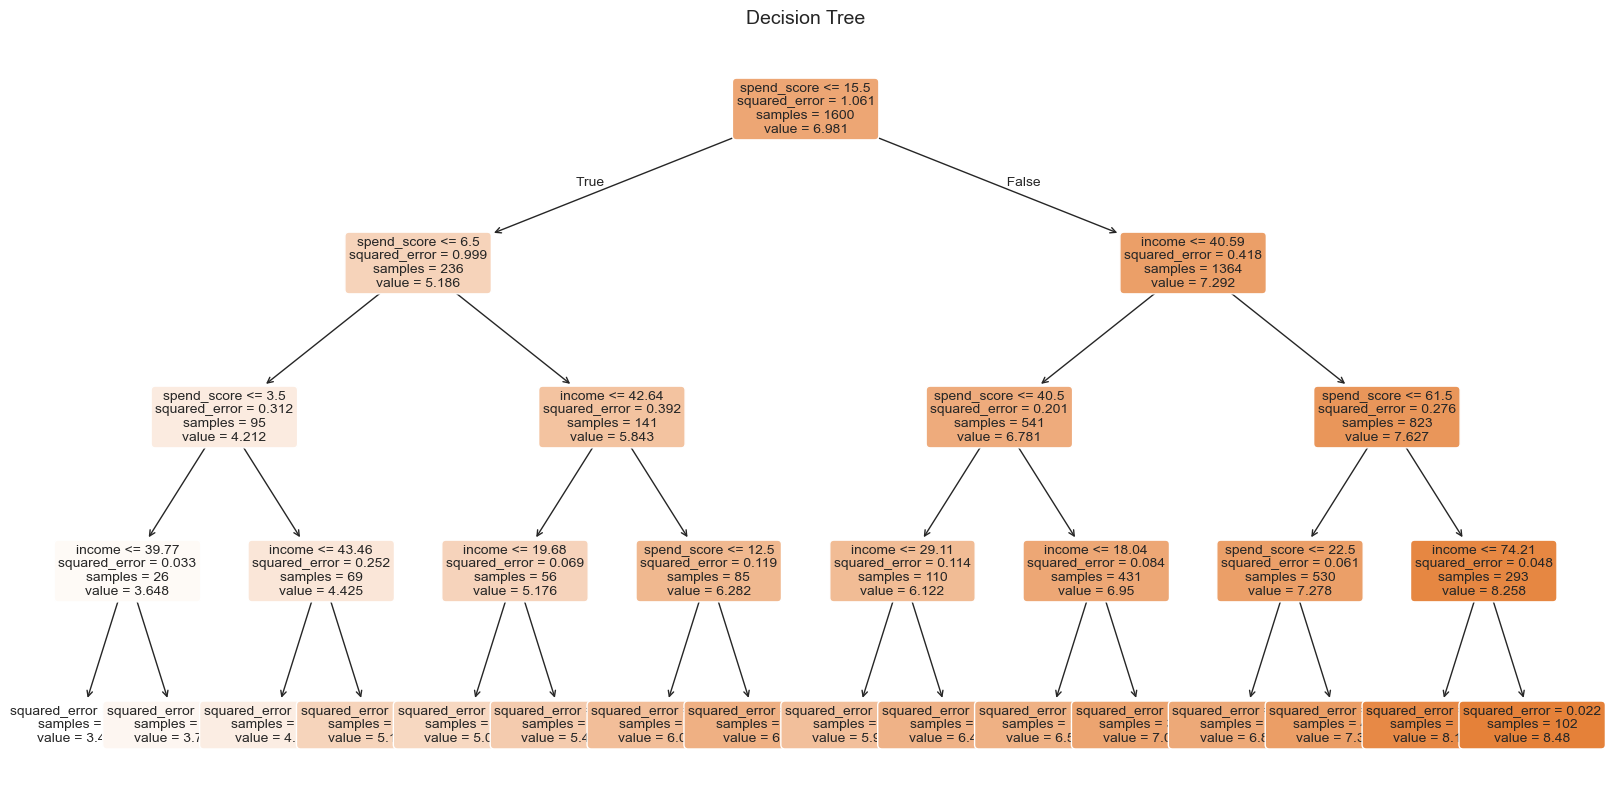

In [18]:
# Define features and target
X = tg_df[['income', 'spend_score']]
y = tg_df['log_loyalty_points']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit the model
tree_model = DecisionTreeRegressor(random_state=42, max_depth=4) 
tree_model.fit(X_train, y_train)

# Predict
y_pred = tree_model.predict(X_test)

# Results
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree")
plt.savefig(f'Decision Tree - Log Loyalty Points.png',dpi=300)
plt.show()

# Clustering

## Scatterplots

<Axes: xlabel='income', ylabel='spend_score'>

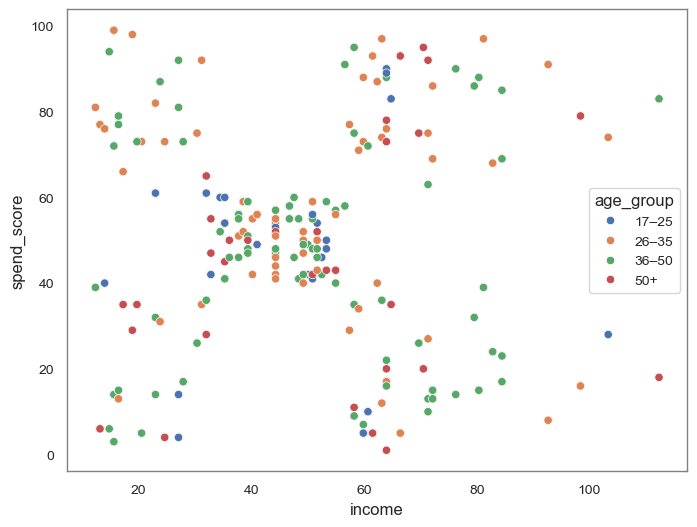

In [19]:
# Group age into buckets
def map_age_group(age):
    if age < 25:
        return "17–25"
    elif age < 35:
        return "26–35"
    elif age < 50:
        return "36–50"
    else:
        return "50+"

tg_df['age_group'] = tg_df['age'].apply(map_age_group)

# Scatterplot with age
sns.scatterplot(x='income',
                y='spend_score',
                data=tg_df,
               hue='age_group')


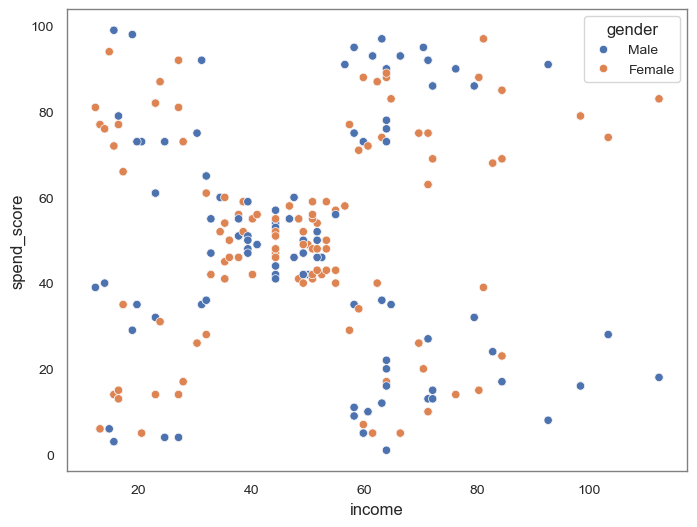

In [20]:
# Scatterplot with gender
sns.scatterplot(x='income',
                y='spend_score',
                data=tg_df,
                hue='gender')
plt.savefig(f'Scatterplot of spend_score v income.png',dpi=300)


### Run silhoutte and elbow method to find optimal number of clusters

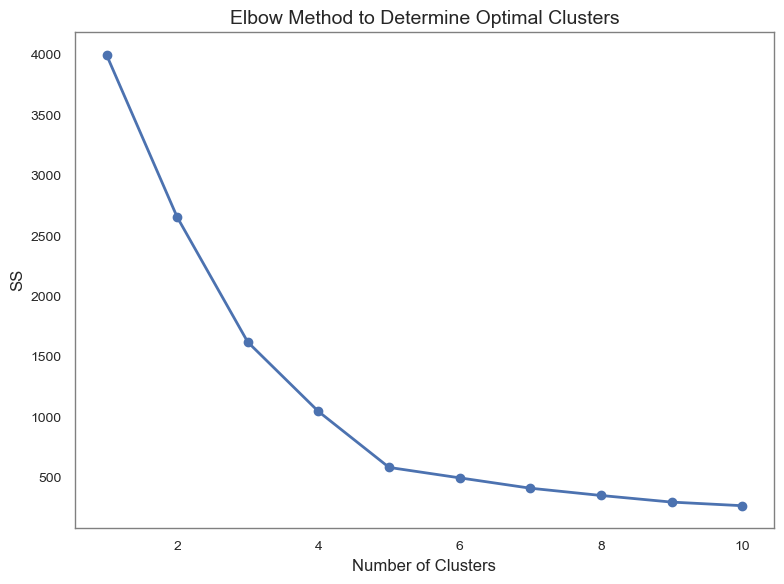

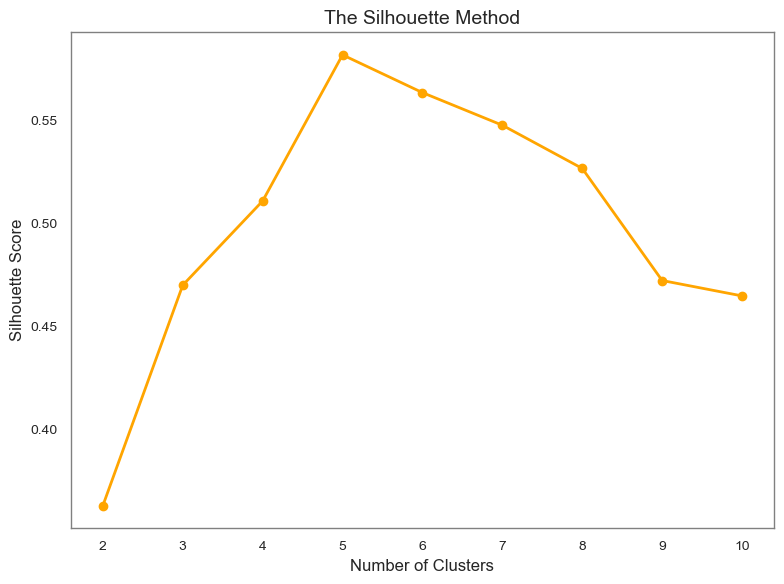


Number of observations per cluster:
 cluster
0    356
1    271
2    330
3    269
4    774
Name: count, dtype: int64


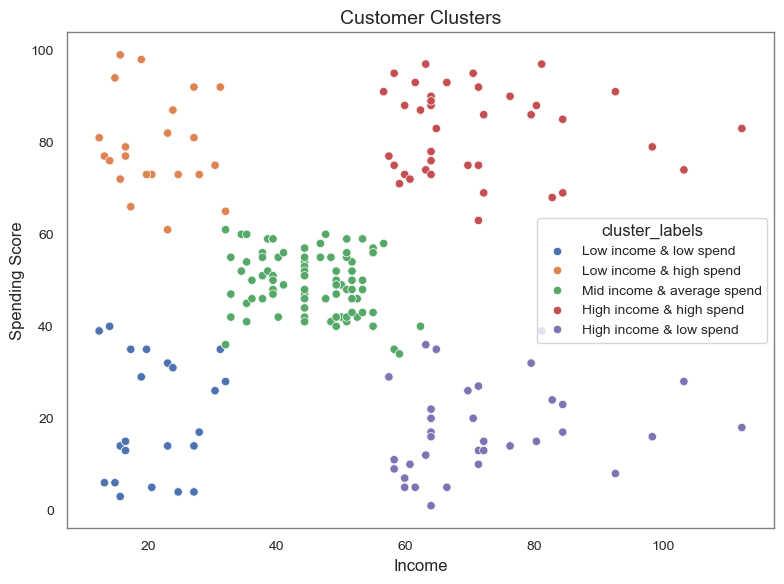


Cluster Summary:
                             income  spend_score
cluster_labels                                 
High income & high spend      73.2         82.0
Low income & high spend       20.4         79.4
Mid income & average spend    44.4         49.5
Low income & low spend        20.4         19.8
High income & low spend       74.8         17.4

Gender Distribution by Cluster:
 gender                      Female  Male
cluster_labels                          
High income & high spend       196   160
High income & low spend        157   173
Low income & high spend        151   118
Low income & low spend         170   101
Mid income & average spend     446   328

Education Distribution by Cluster:
 education                   Basic  PhD  diploma  graduate  postgraduate
cluster_labels                                                         
High income & high spend       17   61       27       190            61
High income & low spend        18   98       26       116            72

In [21]:
# Select features
c_features = ['income', 'spend_score']
X = tg_df[c_features]

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    ss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), ss, marker='o')
plt.title('Elbow Method to Determine Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('SS')
plt.tight_layout()
plt.savefig(f'Elbow Method to Determine Optimal Clusters.png',dpi=300)
plt.show()

# Silhouette Score
silhouette_scores = []
cluster_range = range(2, 11)
for i in cluster_range:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled,
                                              cluster_labels,
                                             metric='euclidean'))

# Plot Silhouette Scores
plt.figure()
plt.plot(cluster_range, silhouette_scores, marker='o', color='orange')
plt.title('The Silhouette Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig(f'The Silhouette Method.png',dpi=300)
plt.show()


# Fit KMeans with optimal number of clusters 
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
tg_df['cluster'] = clusters

# Label clusters
cluster_labels = {
    0: "High income & high spend",
    1: "Low income & low spend",
    2: "High income & low spend",
    3: "Low income & high spend",
    4: "Mid income & average spend"
}
tg_df['cluster_labels'] = tg_df['cluster'].map(cluster_labels)

# Show number of observations per predicted cluster
cluster_sizes = tg_df['cluster'].value_counts().sort_index()
print("\nNumber of observations per cluster:\n", cluster_sizes)

# Plot k-means clusters
plt.figure()
sns.scatterplot(data=tg_df, x='income', y='spend_score', hue='cluster_labels')
plt.title('Customer Clusters')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.grid(False)
plt.tight_layout()
plt.savefig(f'Customer Clusters.png',dpi=300)
plt.show()

# Analyse clusters by gender and education
cluster_summary = tg_df.groupby('cluster_labels')[['income', 'spend_score']].mean().round(1).sort_values(by='spend_score', ascending=False)
cluster_counts = tg_df.groupby(['cluster_labels', 'gender']).size().unstack().fillna(0)
edu_counts = tg_df.groupby(['cluster_labels', 'education']).size().unstack().fillna(0)


print("\nCluster Summary:\n", cluster_summary)
print("\nGender Distribution by Cluster:\n", cluster_counts)
print("\nEducation Distribution by Cluster:\n", edu_counts) 


# NLP

In [22]:
# Subset reviews, summary and product into new dataframe
reviews = tg_df[['review','summary','product']]

# Remove missing data
reviews['review'] = reviews['review'].fillna("").astype(str)
reviews['summary'] = reviews['summary'].fillna("").astype(str)

#Count missing entries
missing_count = tg_df['review'].isna().sum()
print(f"Missing review entries: {missing_count}")

missing_count_sum = tg_df['summary'].isna().sum()
print(f"Missing review entries: {missing_count_sum}")


Missing review entries: 0
Missing review entries: 0


In [23]:
# Convert text to lowercase
reviews['review_clean'] = reviews['review'].apply(lambda x: " ".join(x.lower().split()))
reviews['summary_clean'] = reviews['summary'].apply(lambda x: " ".join(x.lower().split()))

clean_reviews = reviews[['review_clean', 'summary_clean','product']]
clean_reviews.head()

,review_clean,summary_clean,product
0,"when it comes to a dm's screen, the space on t...",the fact that 50% of this space is wasted on a...,453
1,an open letter to galeforce9*: your unpainted ...,another worthless dungeon master's screen from...,466
2,"nice art, nice printing. why two panels are fi...","pretty, but also pretty useless",254
3,amazing buy! bought it as a gift for our new d...,five stars,263
4,as my review of gf9's previous screens these w...,money trap,291


In [25]:
# Remove punctuation.
clean_reviews['review_clean'] = reviews['review_clean'].str.replace('[^\w\s]','')
clean_reviews['summary_clean'] = reviews['summary_clean'].str.replace('[^\w\s]','')

clean_reviews['review_clean'] = clean_reviews['review_clean'].apply(lambda x: re.sub(r"[\.\?\!\,\%\*\'\:\;\"]", '', x))
clean_reviews['summary_clean'] = clean_reviews['summary_clean'].apply(lambda x: re.sub(r"[\.\?\!\,\%\*\'\:\;\"]", '', x))

# Preview the result.
clean_reviews.head()

,review_clean,summary_clean,product
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...,453
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...,466
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,254
3,amazing buy bought it as a gift for our new dm...,five stars,263
4,as my review of gf9s previous screens these we...,money trap,291


In [26]:
# Count duplicate entries for reviews and summary
print(f"Duplicated entries in review column: {clean_reviews['review_clean'].duplicated().sum()}")
print(f"Duplicated entries in summary column: {clean_reviews['summary_clean'].duplicated().sum()}")

Duplicated entries in review column: 49
Duplicated entries in summary column: 647


Despite duplicated entries, it this circumstance it is not required to remove them from analysis

## Word Cloud and word frequency

In [27]:
# Tokenise the words.
clean_reviews['tokens'] = clean_reviews['review_clean'].apply(word_tokenize)

# Preview data.
clean_reviews['tokens'].head()

0    [when, it, comes, to, a, dms, screen, the, spa...
1    [an, open, letter, to, galeforce9, your, unpai...
2    [nice, art, nice, printing, why, two, panels, ...
3    [amazing, buy, bought, it, as, a, gift, for, o...
4    [as, my, review, of, gf9s, previous, screens, ...
Name: tokens, dtype: object

In [28]:
all_tokens = []

for i in range(clean_reviews.shape[0]):
    # Add each token to the list.
    all_tokens = all_tokens + clean_reviews['tokens'][i]

# Calculate the frequency distribution.
fdist = FreqDist(all_tokens)

# Preview data.
fdist

FreqDist({'the': 5454, 'and': 3235, 'a': 3168, 'to': 3164, 'of': 2489, 'i': 2091, 'it': 2089, 'is': 1781, 'this': 1776, 'game': 1688, ...})

In [29]:
# Filter out tokens that are neither alphabets nor numbers (to eliminate punctuation marks, etc.).
tokens = [word for word in all_tokens if word.isalnum()]

In [30]:
# Create a set of English stopwords.
english_stopwords = set(stopwords.words('english'))

# Create a filtered list of tokens without stopwords.
tokens2 = [x for x in tokens if x.lower() not in english_stopwords]

# Define an empty string variable.
tokens2_string = ''

for value in tokens2:
    # Add each filtered token word to the string.
    tokens2_string = tokens2_string + value + ' '

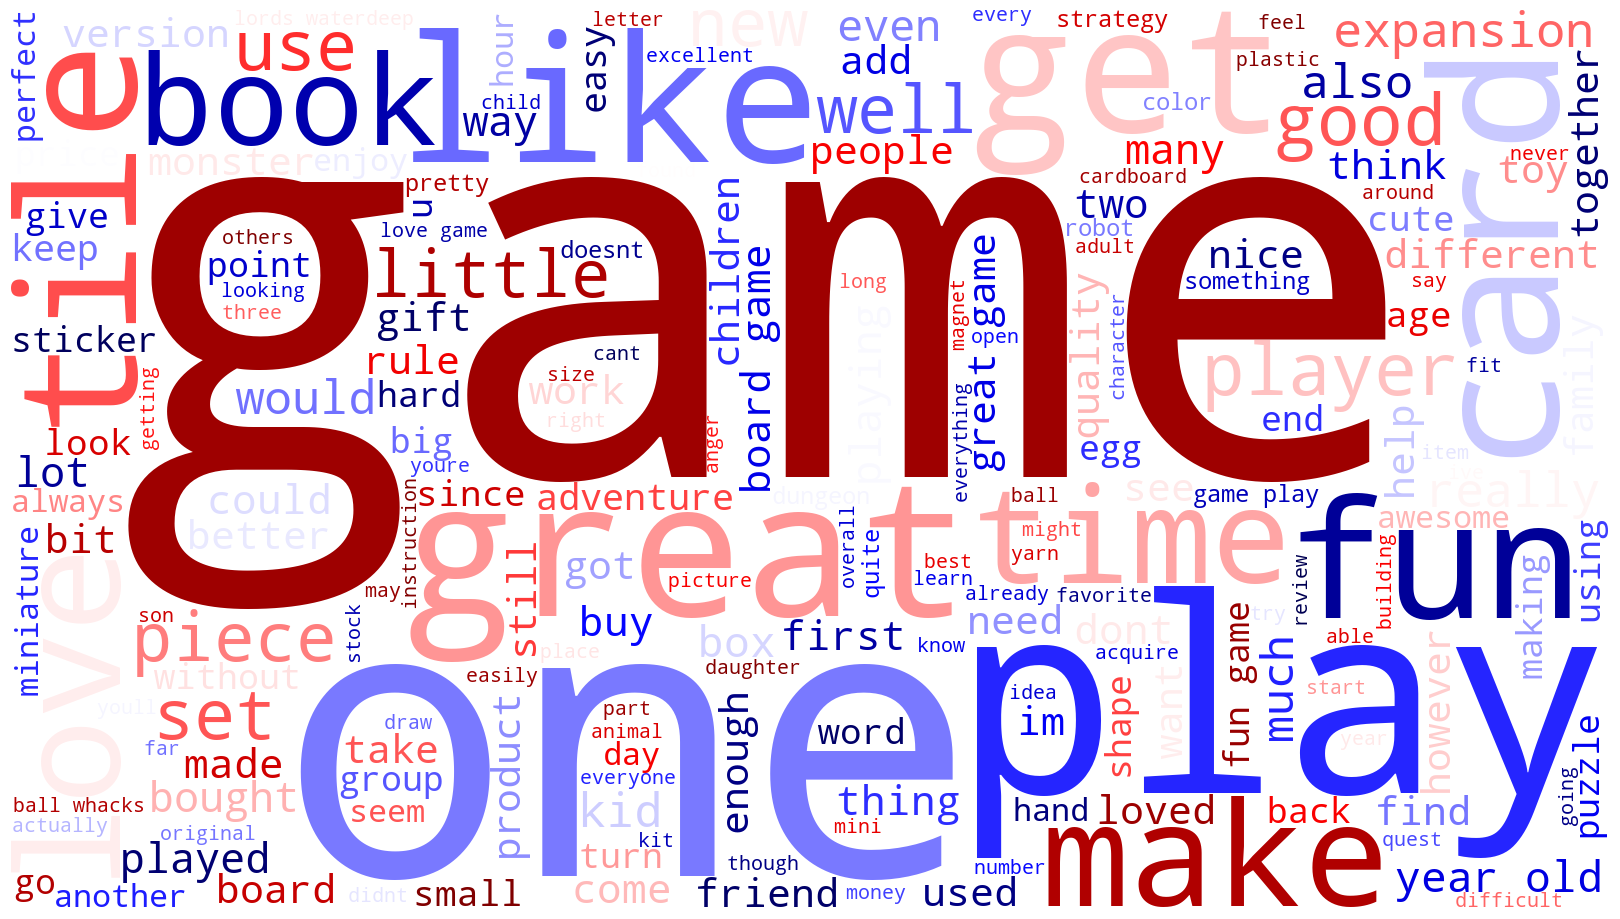

In [31]:
# Create a WordCloud 
word_cloud = WordCloud(width = 1600, height = 900, 
                background_color ='white',
                colormap = 'seismic', 
                stopwords = 'none',
                min_font_size = 10).generate(tokens2_string) 

plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(word_cloud) 
plt.axis('off') 
plt.tight_layout(pad = 0)
plt.savefig(f'Word Cloud.png',dpi=300)
plt.show()

In [32]:
# View the frequency distribution.
fdist1 = FreqDist(tokens2)

# Preview the data.
fdist1

FreqDist({'game': 1688, 'great': 595, 'fun': 553, 'one': 530, 'play': 502, 'like': 414, 'love': 331, 'get': 319, 'really': 318, 'cards': 301, ...})

In [33]:
# Generate a DataFrame from Counter.
counts = pd.DataFrame(Counter(tokens2).most_common(15),
                      columns=['Word', 'Frequency']).set_index('Word')

# Preview data.
counts

,Frequency
Word,
game,1688
great,595
fun,553
one,530
play,502
like,414
love,331
get,319
really,318


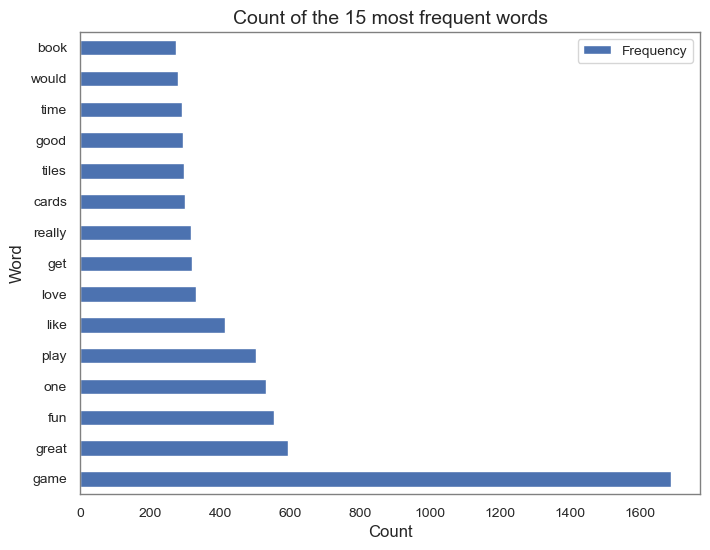

In [34]:
# Set the plot type.
ax = counts.plot(kind='barh')

# Set the labels.
ax.set_xlabel('Count')
ax.set_ylabel('Word')
ax.set_title("Count of the 15 most frequent words")
plt.savefig(f'Count of the 15 most frequent words.png',dpi=300)



## Review Sentiment Polarity

In [35]:
# Define a function to extract a polarity score for the comment.
def generate_polarity(comment):
    return TextBlob(comment).sentiment[0]

# Populate a new column with polarity scores for each comment.
clean_reviews['polarity'] = clean_reviews['review_clean'].apply(generate_polarity)

# Preview the result.
clean_reviews['polarity'].head()

0   -0.036111
1    0.035952
2    0.116640
3    0.578788
4   -0.316667
Name: polarity, dtype: float64

In [36]:
# Define a function to extract a subjectivity score for the comment.
def generate_subjectivity(comment):
    return TextBlob(comment).sentiment[1]

# Populate a new column with subjectivity scores for each comment.
clean_reviews['subjectivity'] = clean_reviews['review_clean'].apply(generate_subjectivity)

# Preview the result.
clean_reviews['subjectivity'].head()

0    0.486111
1    0.442976
2    0.430435
3    0.784848
4    0.316667
Name: subjectivity, dtype: float64

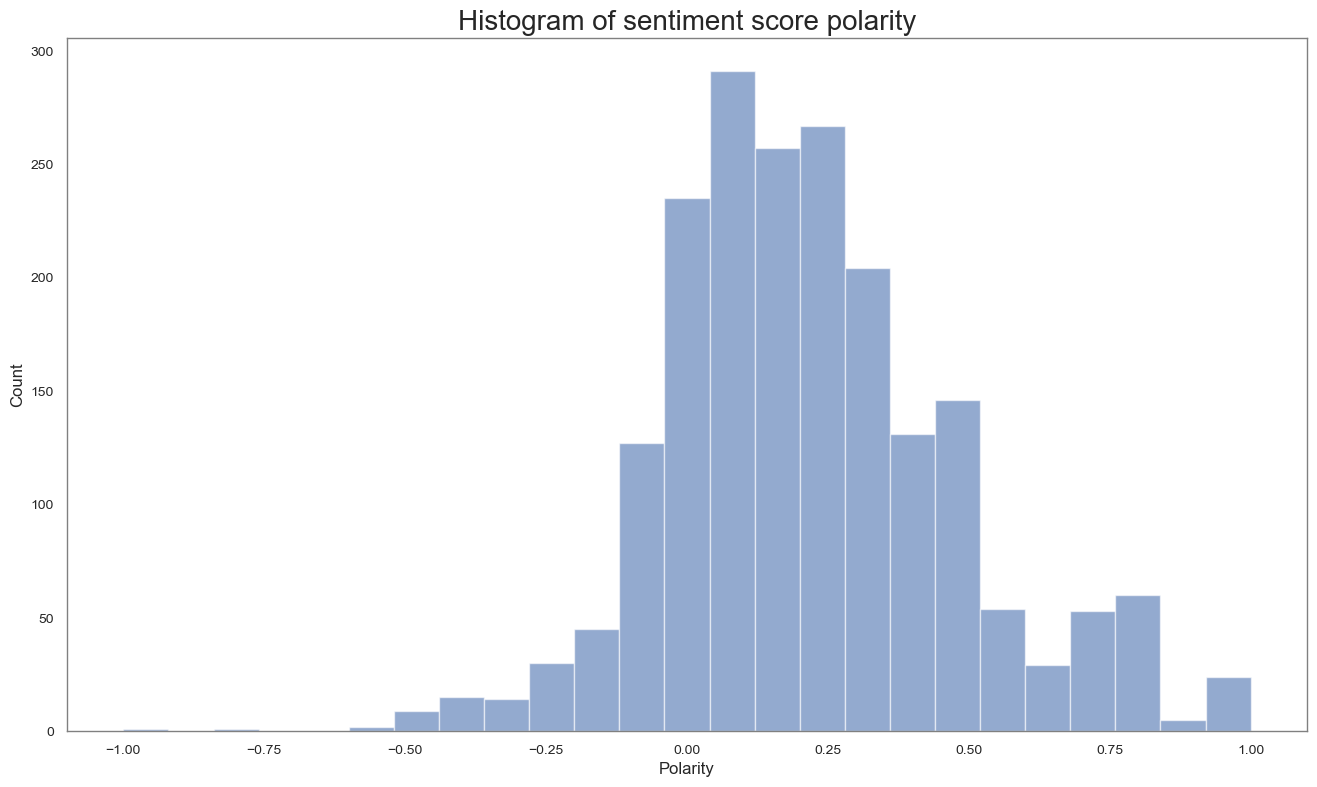

In [37]:
# Set the number of bins.
num_bins = 25

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(clean_reviews['polarity'], num_bins, alpha=0.6)

# Set the labels.
plt.xlabel('Polarity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of sentiment score polarity', fontsize=20)
plt.savefig(f'Histogram of sentiment score polarity.png',dpi=300)
plt.show()

In [38]:
# Create a DataFrame.
positive_sentiment = clean_reviews.nlargest(20, 'polarity')

# Eliminate unnecessary columns.
positive_sentiment = positive_sentiment[['review_clean','polarity']]

# Adjust the column width.
positive_sentiment.style.set_properties(subset=['review_clean','polarity'], **{'width': '1200px'})

,review_clean,polarity
7,came in perfect condition,1.000000
165,awesome book,1.000000
194,awesome gift,1.000000
496,excellent activity for teaching self-management skills,1.000000
524,perfect just what i ordered,1.000000
591,wonderful product,1.000000
609,delightful product,1.000000
621,wonderful for my grandson to learn the resurrection story,1.000000
790,perfect,1.000000
933,awesome,1.000000


In [39]:
count_positive = clean_reviews[clean_reviews['polarity'] > 0].shape[0]

print(f"Number of reviews with polarity score < 0: {count_positive}")

Number of reviews with polarity score < 0: 1614


In [40]:
# Create a DataFrame.
negative_sentiment = clean_reviews.nsmallest(10, 'polarity')

# Eliminate unnecessary columns.
negative_sentiment = negative_sentiment[['review_clean', 'polarity']]

# Adjust the column width.
negative_sentiment.style.set_properties(subset=['review_clean','polarity'], **{'width': '1200px'})

,review_clean,polarity
208,booo unles you are patient know how to measure i didnt have the patience neither did my daughter boring unless you are a craft person which i am not,-1.000000
182,incomplete kit very disappointing,-0.780000
1804,im sorry i just find this product to be boring and to be frank juvenile,-0.583333
364,one of my staff will be using this game soon so i dont know how well it works as yet but after looking at the cards i believe it will be helpful in getting a conversation started regarding anger and what to do to control it,-0.550000
117,i bought this as a christmas gift for my grandson its a sticker book so how can i go wrong with this gift,-0.500000
227,this was a gift for my daughter i found it difficult to use,-0.500000
230,i found the directions difficult,-0.500000
290,instructions are complicated to follow,-0.500000
301,difficult,-0.500000
1524,expensive for what you get,-0.500000


In [41]:
count_negative = clean_reviews[clean_reviews['polarity'] < 0].shape[0]

print(f"Number of reviews with polarity score < 0: {count_negative}")

Number of reviews with polarity score < 0: 306


## VaderSentiment Analysis

In [42]:
# Create an object from the class.
vader = SentimentIntensityAnalyzer()

In [43]:
# Apply vader scores to review column
clean_reviews['vader_scores'] = clean_reviews['review_clean'].apply(vader.polarity_scores)

# Expand dictionary into separate columns
vader_df = clean_reviews['vader_scores'].apply(pd.Series)

# Combine with main DataFrame
clean_reviews = pd.concat([clean_reviews.drop(columns='vader_scores'), vader_df], axis=1)

# OPTIONAL: Sample a few sentences and print compound scores
sentences = clean_reviews['review_clean'].dropna().sample(5, random_state=42).tolist()

for sentence in sentences:
    score = vader.polarity_scores(sentence)['compound']
    print(f'The sentiment value of the sentence:\n\"{sentence}\"\nis: {score}')
    print("="*50)

The sentiment value of the sentence:
"a fun game if you like scrabble and other word games nice that it is in card form for easy storage and use"
is: 0.8885
The sentiment value of the sentence:
"my almost 9 year old loves this pom-pom puppy kit she can do it independently and create adorable puppies we did have to use hot glue to get the body pieces to stay together"
is: 0.8402
The sentiment value of the sentence:
"makes an awesome game even better and opens up more space for a sixth player to join in"
is: 0.8481
The sentiment value of the sentence:
"this game was a little funnot super fantastic although my husband enjoys it a lot more than i do a few things are different from the original like colors and the names of the hotel chains a great game for someone who is very detail oriented"
is: 0.9593
The sentiment value of the sentence:
"or you might really love it some of my friends dreamed about playing this game after the first few games we played that said this game can be addictive 

In [44]:
# Calculate the percentage of the output.
for sentence in sentences:
 print(f'For the sentence "{sentence}"')
 # Calculate the scores.
 polarity = vader.polarity_scores(sentence)
 pos = polarity['pos']
 neu = polarity['neu']
 neg = polarity['neg']
 
 # Display the scores.
 print(f'The sentiment is : positive {round(pos*100,2)}%, neutral {round(neu*100,2)}%, negative {round(neg*100,2)}% ')   
 print("="*50)


For the sentence "a fun game if you like scrabble and other word games nice that it is in card form for easy storage and use"
The sentiment is : positive 37.7%, neutral 62.3%, negative 0.0% 
For the sentence "my almost 9 year old loves this pom-pom puppy kit she can do it independently and create adorable puppies we did have to use hot glue to get the body pieces to stay together"
The sentiment is : positive 22.5%, neutral 77.5%, negative 0.0% 
For the sentence "makes an awesome game even better and opens up more space for a sixth player to join in"
The sentiment is : positive 38.0%, neutral 62.0%, negative 0.0% 
For the sentence "this game was a little funnot super fantastic although my husband enjoys it a lot more than i do a few things are different from the original like colors and the names of the hotel chains a great game for someone who is very detail oriented"
The sentiment is : positive 32.4%, neutral 67.6%, negative 0.0% 
For the sentence "or you might really love it some of 

In [45]:
vader_summary = clean_reviews['compound'].describe().round(3)
print("\nVADER Sentiment Summary (Compound Scores):\n", vader_summary)


VADER Sentiment Summary (Compound Scores):
 count    2000.000
mean        0.640
std         0.389
min        -0.983
25%         0.518
50%         0.778
75%         0.907
max         1.000
Name: compound, dtype: float64


In [46]:
# Classify compound score into sentiment categories
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

clean_reviews['vader_sentiment'] = clean_reviews['compound'].apply(classify_sentiment)

# View proportions
sentiment_distribution = clean_reviews['vader_sentiment'].value_counts(normalize=True).round(3)
print("\nSentiment Distribution:\n", sentiment_distribution)


Sentiment Distribution:
 vader_sentiment
Positive    0.888
Negative    0.065
Neutral     0.046
Name: proportion, dtype: float64


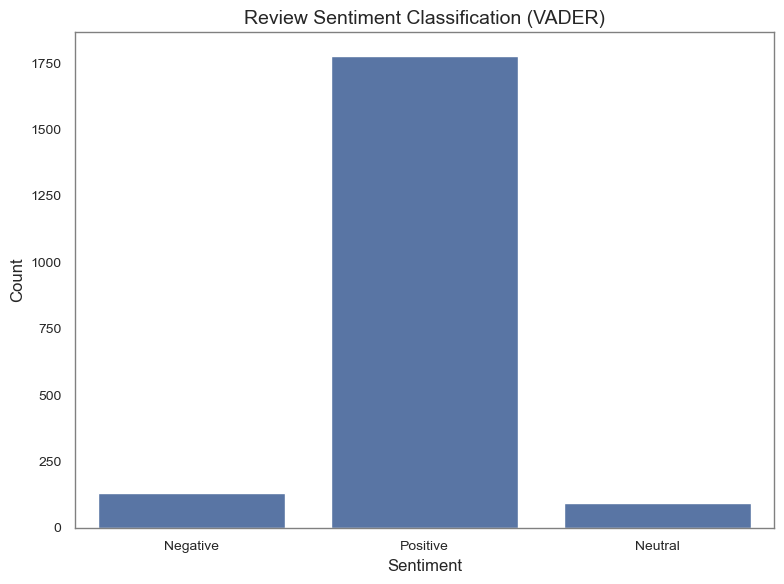

In [47]:
sns.countplot(data=clean_reviews, x='vader_sentiment')
plt.title("Review Sentiment Classification (VADER)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f'Vader Sentiment Classification.png',dpi=300)
plt.show()

In [48]:
pd.set_option('display.max_colwidth', None)
clean_reviews['summary_clean']

0       the fact that 50 of this space is wasted on art (and not terribly informative or needed art 
1                                           another worthless dungeon masters screen from galeforce9
2                                                                     pretty but also pretty useless
3                                                                                         five stars
4                                                                                         money trap
                                                    ...                                             
1995                                                  the perfect word game for mixed ages (with mom
1996                                                                                       super fun
1997                                                                                      great game
1998                                                                                      f

### Analysis of summary_clean

In [49]:
# Populate a new column with polarity scores for each comment.
clean_reviews['sum_polarity'] = clean_reviews['summary_clean'].apply(generate_polarity)

# Preview the result.
clean_reviews['sum_polarity'].head()

0    0.15
1   -0.80
2    0.00
3    0.00
4    0.00
Name: sum_polarity, dtype: float64

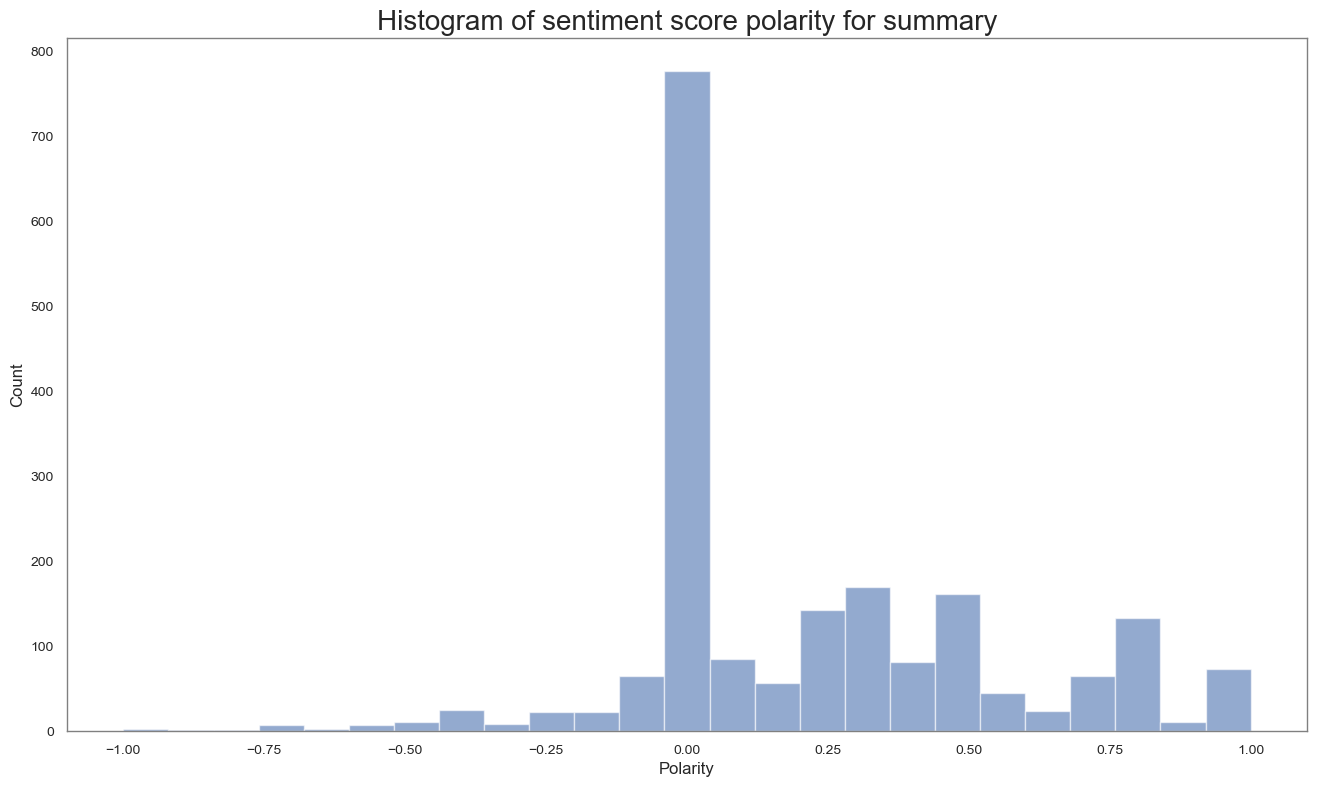

In [50]:
num_bins = 25

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(clean_reviews['sum_polarity'], num_bins, alpha=0.6)

# Set the labels.
plt.xlabel('Polarity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of sentiment score polarity for summary', fontsize=20)
plt.savefig(f'Histogram of sentiment score polarity for summary.png',dpi=300)
plt.show()

In [51]:
# Create a DataFrame.
positive_sum_sentiment = clean_reviews.nlargest(20, 'sum_polarity')

# Eliminate unnecessary columns.
positive_sum_sentiment = positive_sum_sentiment[['summary_clean']]

# Adjust the column width.
positive_sum_sentiment.style.set_properties(subset=['summary_clean'], **{'width': '1200px'})

,summary_clean
6,best gm screen ever
28,wonderful designs
32,perfect
80,theyre the perfect size to keep in the car or a diaper
134,perfect for preschooler
140,awesome sticker activity for the price
161,awesome book
163,he was very happy with his gift
187,awesome
210,awesome and well-designed for 9 year olds


In [52]:
# Create a DataFrame.
neg_sum_sentiment = clean_reviews.nsmallest(20, 'sum_polarity')

# Eliminate unnecessary columns.
neg_sum_sentiment = neg_sum_sentiment[['summary_clean']]

# Adjust the column width.
neg_sum_sentiment.style.set_properties(subset=['summary_clean'], **{'width': '1200px'})

,summary_clean
21,the worst value ive ever seen
208,boring unless you are a craft person which i am
829,boring
1166,before this i hated running any rpg campaign dealing with towns because it
1,another worthless dungeon masters screen from galeforce9
144,disappointed
631,disappointed
793,disappointed
1620,disappointed
363,promotes anger instead of teaching calming methods


In [53]:
# Apply vader scores to review column
clean_reviews['vader_sum_scores'] = clean_reviews['summary_clean'].apply(vader.polarity_scores)

# Expand dictionary into separate columns
vader_sum_df = clean_reviews['vader_sum_scores'].apply(pd.Series)

# Combine with main DataFrame
clean_reviews = pd.concat([clean_reviews.drop(columns='vader_sum_scores'), vader_sum_df], axis=1)

# OPTIONAL: Sample a few sentences and print compound scores
sum_sentences = clean_reviews['summary_clean'].dropna().sample(5, random_state=42).tolist()

for sentence in sum_sentences:
    score_sum = vader.polarity_scores(sentence)['compound']
    print(f'The sentiment value of the sentence:\n\"{sentence}\"\nis: {score_sum}')
    print("="*50)

The sentiment value of the sentence:
"a fun game if you like scrabble and other word games"
is: 0.7003
The sentiment value of the sentence:
"my almost 9 year old loves it"
is: 0.5719
The sentiment value of the sentence:
"five stars"
is: 0.0
The sentiment value of the sentence:
"mediocre game"
is: 0.0
The sentiment value of the sentence:
"if you like rpg/d&d you might love this"
is: 0.7717


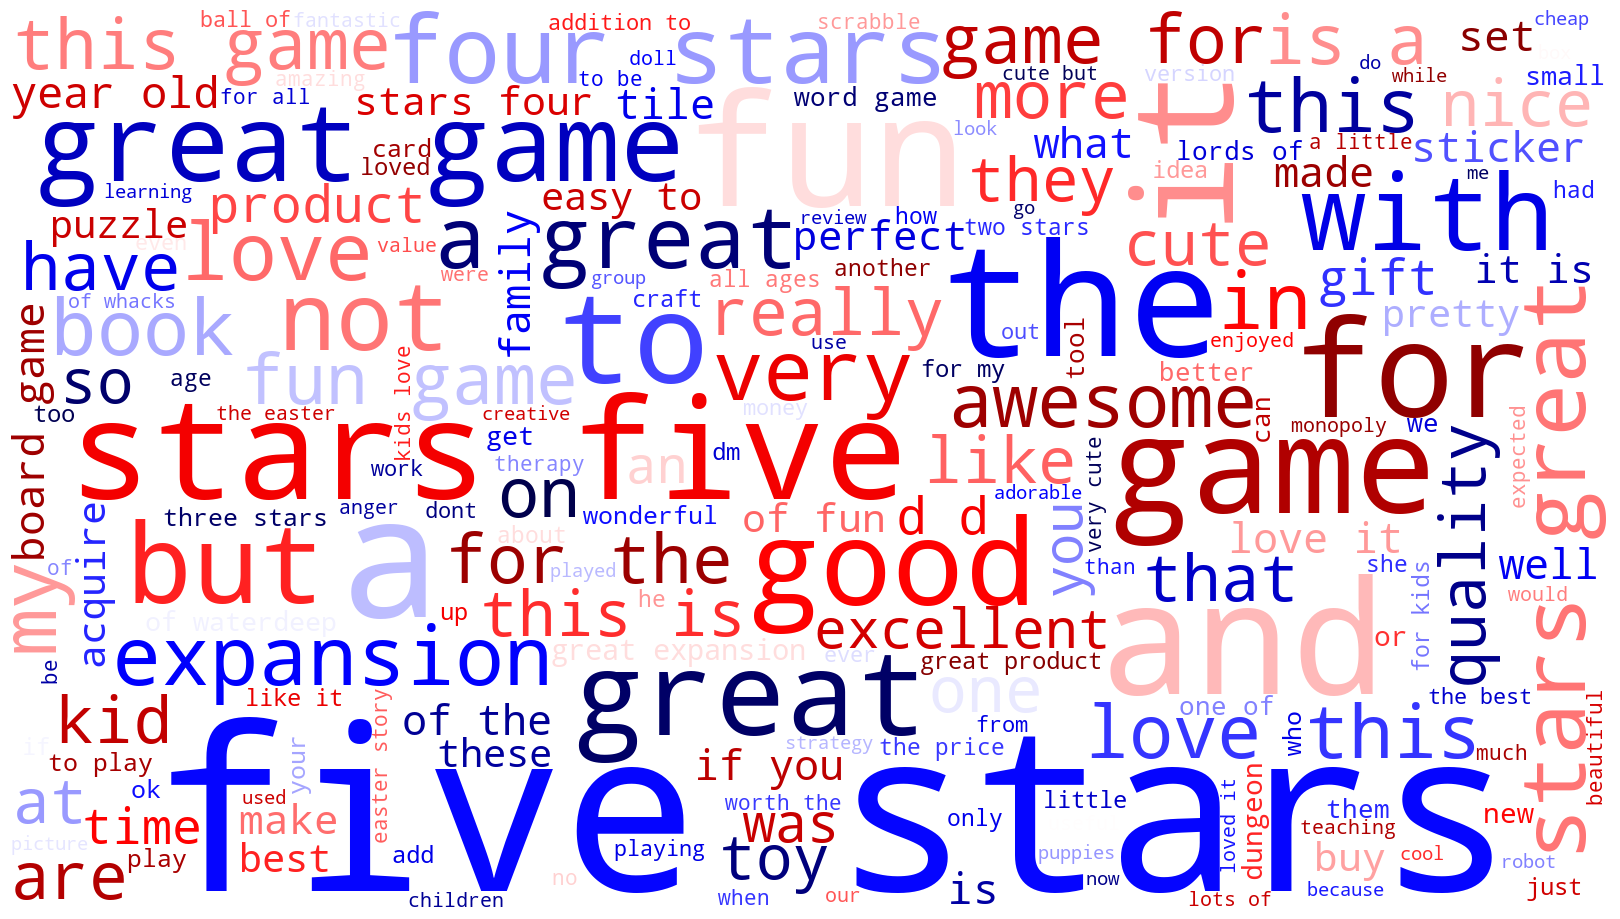

In [54]:
sum_text_data = ' '.join(clean_reviews['summary_clean'].dropna().astype(str))

# Generate the word cloud
sum_word_cloud = WordCloud(
    width=1600,
    height=900,
    background_color='white',
    colormap='seismic',
    stopwords='english',
    min_font_size=10
).generate(sum_text_data)

# Plot the word cloud
plt.figure(figsize=(16, 9))
plt.imshow(sum_word_cloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.savefig('Word_Cloud_Summary_Clean.png', dpi=300)
plt.show()